# 🧠 Modelo 2: Red Neuronal Convolucional (CNN)

Este notebook entrena una CNN básica para la clasificación de imágenes OCT. El modelo se carga desde el archivo `modelos/modelo_cnn.py`.

---

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_cnn as cnn_model

print("✅ Librerías importadas")

2026-03-12 15:14:55.727359: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 15:14:55.772145: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 15:14:56.753860: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ Librerías importadas


In [2]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    
print(gpus[0])

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [4]:
# Descargar y preparar dataset en carpeta local (Disco D)
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")

data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (128, 128) # Mayor resolución para CNN
BATCH_SIZE = 256

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    train_subset_fraction=1, 
    optimize=False
)

✅ Dataset en: /home/palodo2/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (128, 128)
   • Batch size: 256
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      299 batches
Validation: 86 batches
Test:       43 batches



In [5]:
# Crear y compilar el modelo
model = cnn_model.create_cnn(input_shape=(128, 128, 1), num_classes=4)
model = cnn_model.compile_model(model, learning_rate=0.000001)
cnn_model.print_model_summary(model)

Model: "BasicCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,620 (16.36 MB)

 Trainable params: 4,287,620 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


✅ Parámetros totales: 4,287,620


In [7]:
# Entrenamiento
EPOCHS = 1500
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/1500
296/299 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3569 - loss: 7.3380

2026-03-12 15:15:29.621197: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_908', 140 bytes spill stores, 140 bytes spill loads

2026-03-12 15:15:29.639728: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_526', 224 bytes spill stores, 224 bytes spill loads

2026-03-12 15:15:29.709271: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_908', 108 bytes spill stores, 108 bytes spill loads

2026-03-12 15:15:34.307500: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[64,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[227,64,64,32]{3,2,1,0}, f32[227,64,64,64]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01

299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3571 - loss: 7.3125

2026-03-12 15:15:39.862821: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_74', 24 bytes spill stores, 24 bytes spill loads



299/299 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.3829 - loss: 4.7871 - val_accuracy: 0.4905 - val_loss: 1.3395
Epoch 2/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4476 - loss: 1.4076 - val_accuracy: 0.5227 - val_loss: 1.1555
Epoch 3/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4851 - loss: 1.2413 - val_accuracy: 0.5468 - val_loss: 1.1203
Epoch 4/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5035 - loss: 1.2056 - val_accuracy: 0.5655 - val_loss: 1.1004
Epoch 5/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5188 - loss: 1.1753 - val_accuracy: 0.5773 - val_loss: 1.0764
Epoch 6/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5331 - loss: 1.1524 - val_accuracy: 0.5936 - val_loss: 1.0555
Epoch 7/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5441 - loss: 1.1343 - val_accuracy: 0.6048 - val_loss: 1.0409
Epoch 8/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5553 - loss: 1.1205 - val_

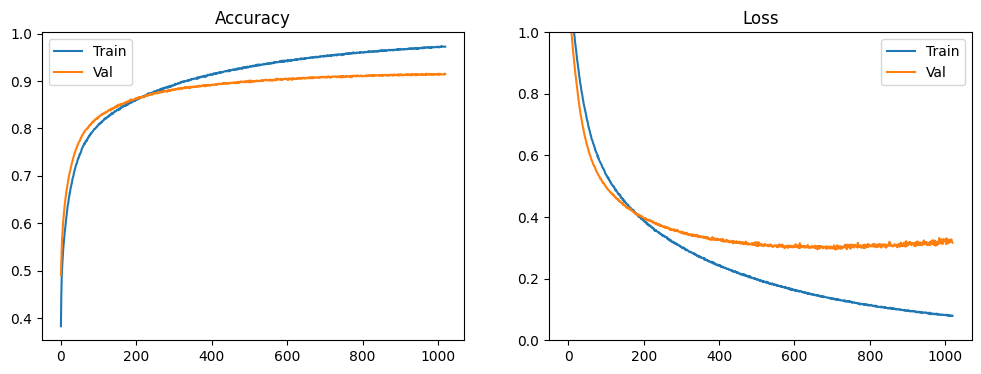

In [8]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.ylim(0, 1)
plt.title('Loss')
plt.legend()
plt.show()

In [9]:
# Evaluación final
loss_train, acc_train = model.evaluate(train_ds, verbose=0)
loss_val, acc_val = model.evaluate(val_ds, verbose=0)
loss_test, acc_test = model.evaluate(test_ds, verbose=0)

print(f"Resultados: Train={acc_train:.4f}, Val={acc_val:.4f}, Test={acc_test:.4f}")
print(f"Parámetros del modelo: {model.count_params():,}")

Resultados: Train=0.9932, Val=0.9156, Test=0.9121
Parámetros del modelo: 4,287,620
